In [49]:
using SymPy, DifferentialEquations, LinearAlgebra, Plots, Latexify
# Latexify.set_default(; starred=true)

In [85]:
using SymPy

# Define symbols
t, Ω, Δ_t, V_nn = symbols("t, Delta,  Ω, Δ_t, V_nn", real=true)

# Define the Hamiltonian
r = Sym[0; 1]  # Assume |1>
g = Sym[1; 0]  # Assume |0>
σ_x = Sym[0 1; 1 0]
n = Sym[0 0; 0 1]
I = Sym[1 0; 0 1]

#Hamiltonian
H = Ω/2 .* kron(I,σ_x) + Δ_t .* kron(I,n) + V_nn .* kron(n,n)

# Diagonalize the Hamiltonian
eigenvals, eigenvecs = eigen(H)

normalized_eigenvecs = [eigenvecs[:,i]./ norm(eigenvecs[:,i])  for i in range(1, length(eigenvals))]

# Initial state
psi_0 = complex(kron(r, g))

# Time evolution operator
U = sum(exp(-im * e * t) * normalized_eigenvecs[i] * normalized_eigenvecs[i]' 
    for (i, e) in enumerate(eigenvals))
psi_t = U * psi_0

psi_t = psi_t ./ norm(psi_t);

In [82]:
E = [eigenvecs[:,i]./ norm(eigenvecs[:,i])  for i in range(1, length(eigenvals))]
latexify(E[1])

"\\begin{equation*}\n\\left[\n\\begin{array}{c}\n\\frac{\\frac{-2 \\cdot \\Omega}{\\Delta} + \\frac{2 \\cdot \\left( \\frac{\\Omega}{2} - \\frac{\\sqrt{\\Delta^{2} + \\Omega^{2}}}{2} \\right)}{\\Delta}}{\\sqrt{\\left( \\mathrm{Abs}\\left( \\frac{2 \\cdot \\Omega}{\\Delta} - \\frac{2 \\cdot \\left( \\frac{" ⋯ 75 bytes ⋯ "ht) \\right)^{2} + 1}} \\\\\n\\frac{1}{\\sqrt{\\left( \\mathrm{Abs}\\left( \\frac{2 \\cdot \\Omega}{\\Delta} - \\frac{2 \\cdot \\left( \\frac{\\Omega}{2} - \\frac{\\sqrt{\\Delta^{2} + \\Omega^{2}}}{2} \\right)}{\\Delta} \\right) \\right)^{2} + 1}} \\\\\n0 \\\\\n0 \\\\\n\\end{array}\n\\right]\n\\end{equation*}\n"

In [ ]:
n = Sym[0 0; 0 1]
P_e = simplify(psi_t' * kron(I,n) * psi_t)

println("Probability in excited state:")
latexify(P_e)

In [65]:
length(eigenvals)

4

In [54]:
f(t_val,Delta_val,Omega_val) = P_e.subs([(t, t_val),(Delta, Delta_val),(Omega, Omega_val)]) |> N

f (generic function with 1 method)

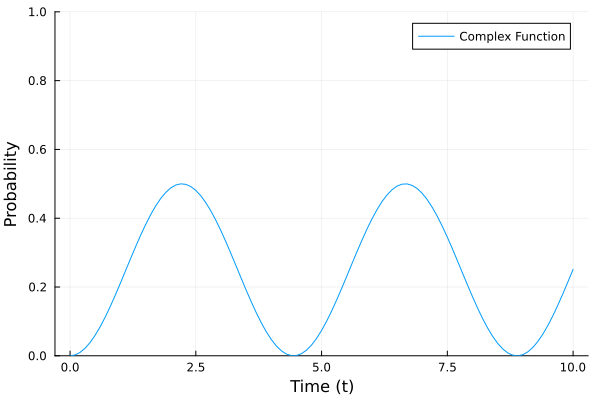

In [55]:
t_vals = 0:0.1:10  # Define time range
Delta_val = 1
Omega_val = 1.0
y_vals = [f(t, Delta_val, Omega_val) for t in t_vals]

plot(t_vals, real(y_vals), ylim=[0,1], label="Complex Function", xlabel="Time (t)", ylabel="Probability")